➡️标量导数
    梯度————将导数拓展到向量



   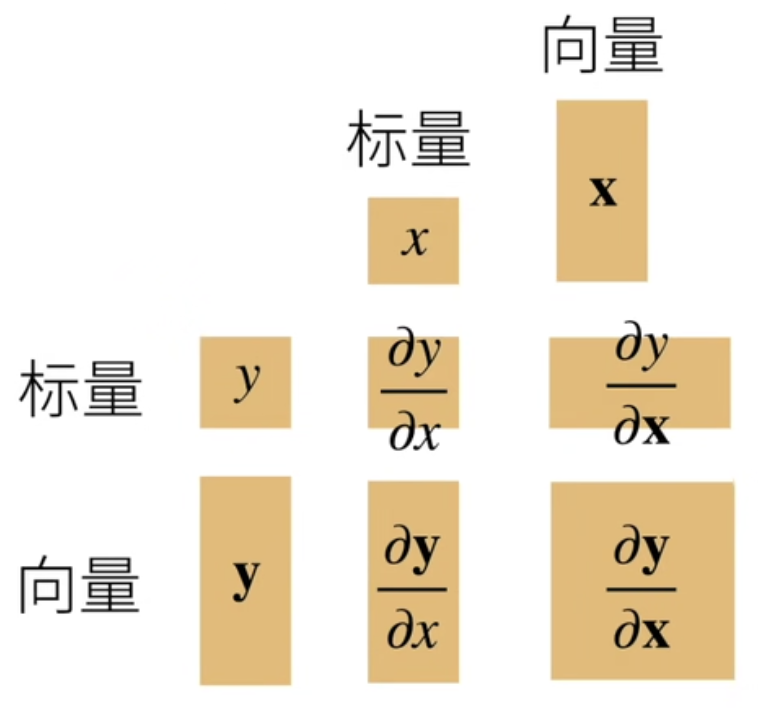



   
    ～ 标量y（y为变量）关于 列向量x 的导数是行向量 ∂y/∂x=[∂y/(∂x_1), ∂y/(∂x_2), ···, ∂y/(∂x_n)]
    ～ 梯度指向等高线值最大的方向，与等高线正交
    ====================================
    ～ 列向量y 关于 标量x 的导数是列向量 ∂y/∂x=[∂(y_1)/∂x, ∂(y_2)/∂x, ···, ∂(y_n)/∂x]
    ～ y为列向量为分子布局法， y为行向量则为分母布局法
    ====================================
    列向量y 关于 列向量x 的导数是矩阵 ∂y/∂x=[[∂(y_1)/(∂x_1), ∂(y_1)/(∂x_2), ···, ∂(y_1)/(∂x_n)],[∂(y_2)/(∂x_1), ∂(y_2)/(∂x_2), ···, ∂(y_3)/(∂x_n)], ···]

➡️向量链式法则

    x为向量，y为标量，u为标量
    ∂y/∂x=(∂y/∂u)*(∂u/∂x)，y(1,n) u(1) x(1,n)

    x为向量，y为标量，u为向量
    ∂y/∂x=(∂y/∂u)*(∂u/∂x)，y(1,n) u(1,k) x(k,n)

    x,y,u都为向量
    ∂y/∂x=(∂y/∂u)*(∂u/∂x)，y(m,n) u(m,k) x(k,n)

➡️自动求导
     ～计算一个函数在指定值上的导数
     
     自动求导的两种模式：
        1.正向累积————由里层向外层计算 ∂y/∂x=(∂y/∂u)*(∂u/∂x) (∂y/∂u)<——(∂u/∂x)
        2.反向累积————由外层向里层计算 (∂y/∂u)——>(∂u/∂x)


假设y=2x.Tx, 对列向量x求导

In [34]:
import torch
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

在计算y关于x的梯度之前，我们需要一个地方来存储梯度

In [35]:
x.requires_grad_(True) # Enable gradient tracking, 等价于x = torch.arange(4.0, requires_grad=True)
x.grad # None, 因为还没有计算过梯度

In [36]:
y = 2 * torch.dot(x, x)
y # tensor(28., grad_fn=<MulBackward0>) grad_fn表示y是由x计算出来的

tensor(28., grad_fn=<MulBackward0>)

In [37]:
y.backward() # 计算y对x的梯度
x.grad # tensor([ 0.,  4.,  8., 12.])

tensor([ 0.,  4.,  8., 12.])

In [38]:
x.grad == 4 * x # 计算y对x的梯度，dy/dx = 4x

tensor([True, True, True, True])

In [ ]:
# 在默认情况下，x.grad是累积的，因此每次计算梯度时都要清除之前的值
x.grad.zero_() # 清除之前的值, _表示原地操作，写入
y = x.sum() #重新定义y
y.backward() # 计算y对x的梯度
x.grad # tensor([1., 1., 1., 1.])

tensor([1., 1., 1., 1.])

在深度学习中，我们的目的不是计算微分矩阵，而是批量中每个样本单独计算的偏导数之和

In [ ]:
x.grad.zero_() # 清除之前的值
y = x * x
# 等价于y.backward(torch.ones(len(x))) 
y = y.sum().backward() # 重新定义y, 这里y被设定为一个向量（y = x * x），向量对向量求导获得的是一个矩阵，但是深度学习中一般不这么做，所以通过y.sum()将向量重新变为标量
x.grad # tensor([0., 2., 4., 6.])

tensor([0., 2., 4., 6.])

In [44]:
x.grad.zero_() # 清除之前的值
y = x * x
u = y.detach() # detach()函数返回一个新的tensor，和原来的tensor共享内存，但是不需要计算梯度, 最终u为标量
z = u * x
z.sum().backward() # 计算z对x的梯度
x.grad == u 

tensor([True, True, True, True])

In [45]:
x.grad.zero_() # 清除之前的值
y.sum().backward()
x.grad # tensor([0., 2., 4., 6.])

tensor([0., 2., 4., 6.])

即使构建函数的计算过程中需要用到python的控制流(如循环、判断或任意函数的调用)，我们仍可以计算获得变量的梯度